# Efficient ML Systems Project
## Results Visualization and Analysis

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
with open("/content/summaries.json", "r") as f:
    data = json.load(f)


In [3]:
rows = []

for key, val in data.items():
    method_name = val["method"]

    # Detect split
    if "1pct" in method_name:
        split = "1%"
    elif "5pct" in method_name:
        split = "5%"
    elif "10pct" in method_name:
        split = "10%"
    elif "100pct" in method_name:
        split = "100%"

    # Detect method
    if "head" in method_name:
        method = "Head"
    elif "lora_qv_r4" in method_name:
        method = "LoRA r=4"
    elif "lora_qv_r8" in method_name:
        method = "LoRA r=8"
    elif "lora_qv_r16" in method_name:
        method = "LoRA r=16"
    elif "full_ft" in method_name:
        method = "Full FT"

    rows.append({
        "split": split,
        "method": method,
        "accuracy": val["eval_accuracy"],
        "f1": val["eval_f1_macro"],
        "train_time": val["train_time_sec"],
        "params": val["trainable_params"],
        "gpu_mem": val["peak_gpu_mem_mb"]
    })

# Create DataFrame
df = pd.DataFrame(rows)

df["split"] = pd.Categorical(df["split"], ["1%", "5%", "10%", "100%"], ordered=True)

# Sort for clean visualization
df = df.sort_values(by=["split", "method"])

# Display
df.head()

,split,method,accuracy,f1,train_time,params,gpu_mem
4,1%,Full FT,0.9436,0.943559,359.160531,66955010,2382.863281
0,1%,Head,0.8778,0.877543,109.236886,592130,978.542969
3,1%,LoRA r=16,0.9420,0.941970,193.642290,887042,2849.103516
1,1%,LoRA r=4,0.9384,0.938361,194.162993,665858,2837.275391
2,1%,LoRA r=8,0.9406,0.940573,206.887760,739586,1784.869629


## Model Accuracy Across Different Dataset Sizes

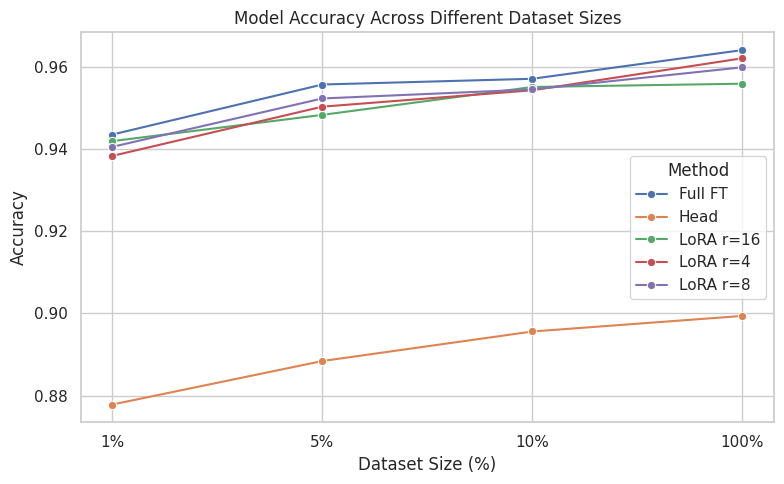

In [4]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=df,
    x="split",
    y="accuracy",
    hue="method",
    marker="o"
)

plt.xlabel("Dataset Size (%)")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Across Different Dataset Sizes")

plt.legend(title="Method")
plt.tight_layout()

plt.savefig("accuracy_vs_split.png", dpi=300)
plt.show()

## Training Time Analysis

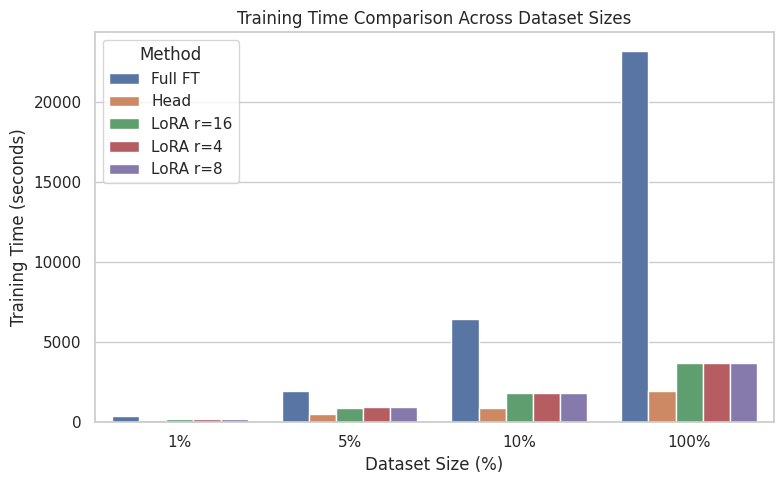

In [5]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="split",
    y="train_time",
    hue="method"
)

plt.xlabel("Dataset Size (%)")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison Across Dataset Sizes")

plt.legend(title="Method")
plt.tight_layout()

plt.savefig("training_time.png", dpi=300)
plt.show()

## Parameter Efficiency

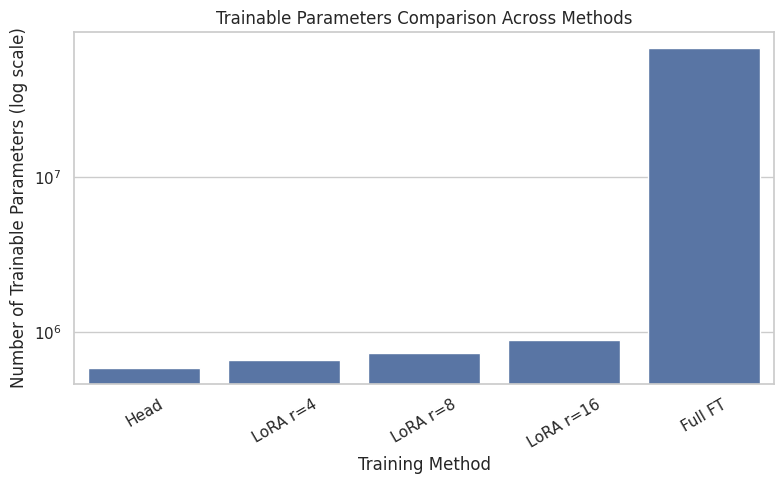

In [6]:
plt.figure(figsize=(8,5))

method_order = ["Head", "LoRA r=4", "LoRA r=8", "LoRA r=16", "Full FT"]
df["method"] = pd.Categorical(df["method"], categories=method_order, ordered=True)
df = df.sort_values("method")

sns.barplot(
    data=df,
    x="method",
    y="params"
)

plt.xlabel("Training Method")
plt.ylabel("Number of Trainable Parameters (log scale)")
plt.title("Trainable Parameters Comparison Across Methods")

plt.yscale("log")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("params.png", dpi=300)
plt.show()

## Efficiency Tradeoff

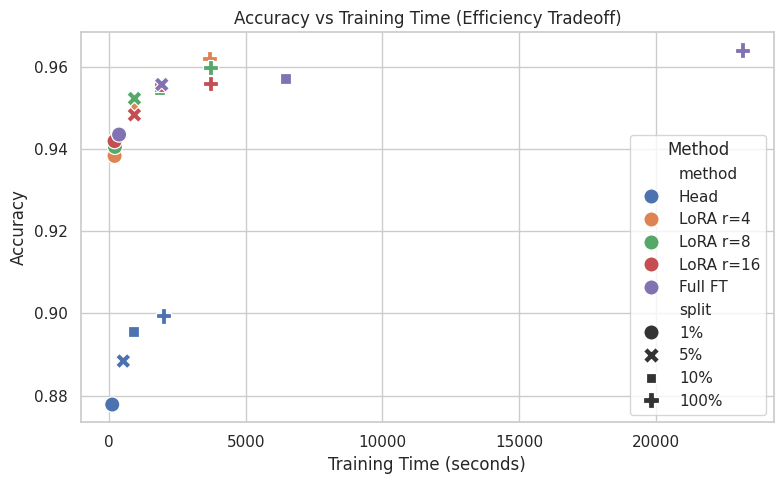

In [7]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="train_time",
    y="accuracy",
    hue="method",
    style="split",
    s=120
)

plt.xlabel("Training Time (seconds)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Training Time (Efficiency Tradeoff)")

plt.legend(title="Method")
plt.tight_layout()

plt.savefig("efficiency_tradeoff.png", dpi=300)
plt.show()

In [8]:
summary = df.groupby(["split", "method"]).mean().reset_index()
summary

/tmp/ipykernel_22691/3391294065.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(["split", "method"]).mean().reset_index()


,split,method,accuracy,f1,train_time,params,gpu_mem
0,1%,Head,0.8778,0.877543,109.236886,592130.0,978.542969
1,1%,LoRA r=4,0.9384,0.938361,194.162993,665858.0,2837.275391
2,1%,LoRA r=8,0.9406,0.940573,206.887760,739586.0,1784.869629
3,1%,LoRA r=16,0.9420,0.941970,193.642290,887042.0,2849.103516
4,1%,Full FT,0.9436,0.943559,359.160531,66955010.0,2382.863281
5,5%,Head,0.8884,0.888265,514.312110,592130.0,2299.858887
6,5%,LoRA r=4,0.9504,0.950375,931.600194,665858.0,3114.044922
7,5%,LoRA r=8,0.9524,0.952375,921.069584,739586.0,3114.654297
8,5%,LoRA r=16,0.9484,0.948376,919.700716,887042.0,3103.873047
9,5%,Full FT,0.9558,0.955780,1920.634453,66955010.0,3247.911621


In [9]:
summary.to_csv("final_results.csv", index=False)